aaa


d:\anacondaaa\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"



训练集: (60000, 28, 28) 标签: (60000,)
测试集: (10000, 28, 28) 标签: (10000,)
Train data shape: (55000, 28, 28)
Validation data shape: (5000, 28, 28)
Test data shape: (10000, 28, 28)
Shape of features (55000, 28, 28, 1) (5000, 28, 28, 1) (10000, 28, 28, 1)



Epoch 1/3


1719/1719 [==============================] - 55s 31ms/step - loss: 0.7218 - accuracy: 0.7468 - val_loss: 0.4085 - val_accuracy: 0.8508
Epoch 2/3
1719/1719 [==============================] - 38s 22ms/step - loss: 0.4282 - accuracy: 0.8533 - val_loss: 0.3273 - val_accuracy: 0.8800
Epoch 3/3
1719/1719 [==============================] - 69s 40ms/step - loss: 0.3727 - accuracy: 0.8759 - val_loss: 0.3113 - val_accuracy: 0.8824

训练总耗时: 162.36 秒
313/313 [==============================] - 4s 13ms/step - loss: 0.3414 - accuracy: 0.8783

测试集准确率: 0.8783

=== 训练集样本展示 ===


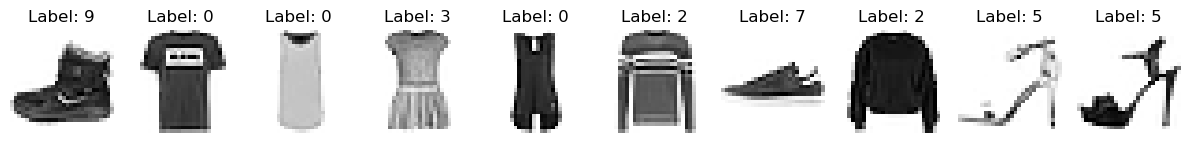


=== 训练过程曲线 ===


C:\Users\ailiiiiice\AppData\Local\Temp\ipykernel_8732\2780278125.py:133: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
C:\Users\ailiiiiice\AppData\Local\Temp\ipykernel_8732\2780278125.py:133: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.tight_layout()
C:\Users\ailiiiiice\AppData\Local\Temp\ipykernel_8732\2780278125.py:133: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
C:\Users\ailiiiiice\AppData\Local\Temp\ipykernel_8732\2780278125.py:133: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from current font.
  plt.tight_layout()
C:\Users\ailiiiiice\AppData\Local\Temp\ipykernel_8732\2780278125.py:133: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.tight_layout()
C:\Users\ailiiiiice\AppData\Local\Temp\ipykernel_8732\2780278125.py:133: UserWarning: Glyph 26354 (\N{CJK

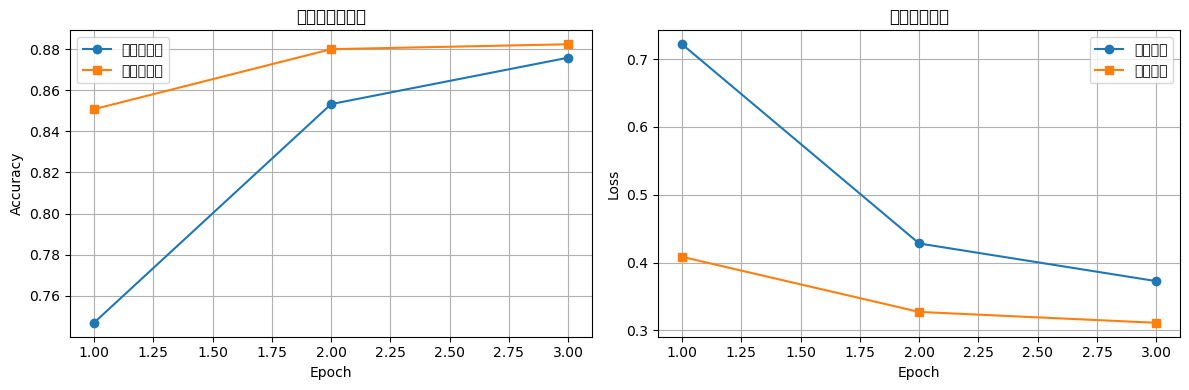


真实标签: [4 5 7 3 4 1 2 4 8 0]
预测标签: [4 5 5 3 4 1 2 2 8 0]


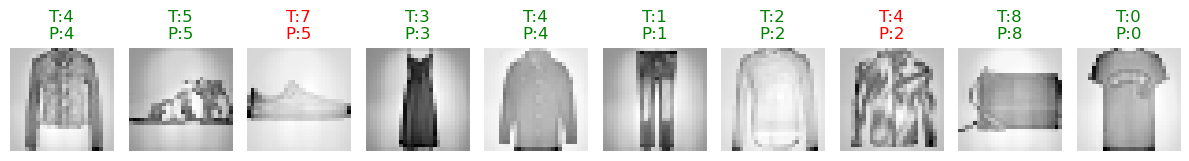


=== 预测错误样本展示 ===


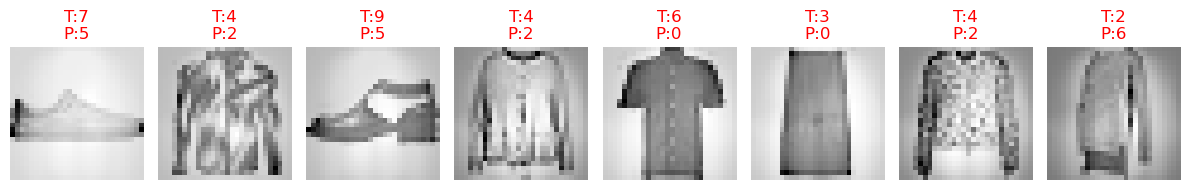


共找到 1217 个预测错误样本，展示前8个


In [1]:
#import libraries
print("aaa")
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import gzip
import time
from functools import partial

# 设置随机种子保证结果可复现
np.random.seed(42) 
tf.random.set_seed(42)

# ========== 1. 加载本地MNIST数据集 ==========
data_dir = r"D:\code\C++\pyu\\"  # 数据集路径，保持原配置
def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

# 读取数据
X_train_full = load_mnist_images(data_dir + "train-images-idx3-ubyte.gz")
y_train_full = load_mnist_labels(data_dir + "train-labels-idx1-ubyte.gz")
X_test = load_mnist_images(data_dir + "t10k-images-idx3-ubyte.gz")
y_test = load_mnist_labels(data_dir + "t10k-labels-idx1-ubyte.gz")

# 数据集形状打印
print("训练集:", X_train_full.shape, "标签:", y_train_full.shape)
print("测试集:", X_test.shape, "标签:", y_test.shape)

# ========== 2. 划分训练/验证集 ==========
X_train = X_train_full[:55000]
y_train = y_train_full[:55000]
X_valid = X_train_full[55000:] 
y_valid = y_train_full[55000:] 

print("Train data shape:",X_train.shape)
print("Validation data shape:",X_valid.shape)
print("Test data shape:",X_test.shape)

# ========== 3. 数据标准化 + 增加通道维度 ==========
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True)
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]
print ("Shape of features", X_train.shape, X_valid.shape, X_test.shape)

# ========== 4. 构建CNN模型 ==========
DefaultConv2D = partial(keras.layers.Conv2D,
                    kernel_size=3, activation='relu', padding="SAME")
model = keras.models.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=128),  
    DefaultConv2D(filters=128),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])

# ========== 5. 模型训练 + 计时（参考4.txt） ==========
start_time = time.time()
history = model.fit(X_train, y_train, epochs=3, validation_data=(X_valid, y_valid))
end_time = time.time()
print(f"\n训练总耗时: {round(end_time - start_time, 2)} 秒")

# ========== 6. 模型评估 ==========
results = model.evaluate(X_test, y_test, verbose=1)
print(f"\n测试集准确率: {results[1]:.4f}")

# ========== 7. 【图形化展示 1】随机样本可视化（参考4.txt绘图风格） ==========
def plot_mnist_samples(images, labels, n=10):
    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        # 去掉通道维度，还原28*28原图
        plt.imshow(images[i].squeeze(), cmap="Greys")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# 展示前10个训练样本
print("\n=== 训练集样本展示 ===")
plot_mnist_samples(X_train_full, y_train_full, n=10)

# ========== 8. 【图形化展示 2】训练过程曲线（损失、准确率） ==========
def plot_training_curves(history):
    history_data = history.history
    epochs = range(1, len(history_data['accuracy']) + 1)

    plt.figure(figsize=(12, 4))
    # 准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_data['accuracy'], 'o-', label='训练准确率')
    plt.plot(epochs, history_data['val_accuracy'], 's-', label='验证准确率')
    plt.title('准确率变化曲线')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_data['loss'], 'o-', label='训练损失')
    plt.plot(epochs, history_data['val_loss'], 's-', label='验证损失')
    plt.title('损失变化曲线')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("\n=== 训练过程曲线 ===")
plot_training_curves(history)

# ========== 9. 【图形化展示 3】预测结果对比图 ==========
# 选取测试集10张图片做预测
X_new = X_test[10:20]
y_true = y_test[10:20]
y_pred_prob = model.predict(X_new, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print(f"\n真实标签: {y_true}")
print(f"预测标签: {y_pred}")

# 绘制 真实值 vs 预测值 对比图
plt.figure(figsize=(12, 3))
for i in range(len(X_new)):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_new[i].squeeze(), cmap="Greys")
    # 预测正确标绿色，错误标红色
    color = "green" if y_pred[i] == y_true[i] else "red"
    plt.title(f"T:{y_true[i]}\nP:{y_pred[i]}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

# ========== 10. 【图形化展示 4】错误预测样本可视化 ==========
def plot_error_samples(X_test, y_test, model, max_err=8):
    y_all_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    # 筛选预测错误的样本
    error_idx = np.where(y_all_pred != y_test)[0]
    if len(error_idx) == 0:
        print("\n恭喜！无预测错误样本")
        return
    
    # 取前max_err个错误样本
    select_err = error_idx[:max_err]
    n = len(select_err)
    plt.figure(figsize=(1.5*n, 3))
    for i, idx in enumerate(select_err):
        plt.subplot(1, n, i+1)
        plt.imshow(X_test[idx].squeeze(), cmap="Greys")
        plt.title(f"T:{y_test[idx]}\nP:{y_all_pred[idx]}", color="red")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"\n共找到 {len(error_idx)} 个预测错误样本，展示前{len(select_err)}个")

print("\n=== 预测错误样本展示 ===")
plot_error_samples(X_test, y_test, model, max_err=8)